In [523]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from collections import defaultdict, deque
from copy import deepcopy


In [524]:
df = pd.read_csv('premier_league.csv')
dp = pd.read_csv('2016-17.csv')

In [525]:
dp.head()

,Season,Date,Time,Round,HomeTeam,AwayTeam,FTHG,FTAG,HTHG,HTAG,FTR,Venue,City,Attendance,Referee
0,2016-17,2016-08-13,12:30,1,Hull,Leicester City,2,1,1.0,0.0,H,NaN,NaN,NaN,NaN
1,2016-17,2016-08-13,15:00,1,Burnley,Swansea,0,1,0.0,0.0,A,NaN,NaN,NaN,NaN
2,2016-17,2016-08-13,NaN,1,Crystal Palace,West Bromwich Albion,0,1,0.0,0.0,A,NaN,NaN,NaN,NaN
3,2016-17,2016-08-13,NaN,1,Everton,Tottenham Hotspur,1,1,1.0,0.0,D,NaN,NaN,NaN,NaN
4,2016-17,2016-08-13,NaN,1,Middlesbrough,Stoke City,1,1,1.0,0.0,D,NaN,NaN,NaN,NaN


In [526]:
df.head()

,Season,Date,Time,Round,HomeTeam,AwayTeam,FTHG,FTAG,HTHG,HTAG,FTR,Venue,City,Attendance,Referee
0,2017-18,2017-08-11,19:45,1,Arsenal,Leicester City,4,3,2.0,2.0,H,NaN,NaN,NaN,NaN
1,2017-18,2017-08-12,12:30,1,Watford,Liverpool,3,3,2.0,1.0,D,NaN,NaN,NaN,NaN
2,2017-18,2017-08-12,15:00,1,Chelsea,Burnley,2,3,0.0,3.0,A,NaN,NaN,NaN,NaN
3,2017-18,2017-08-12,NaN,1,Crystal Palace,Huddersfield Town,0,3,0.0,2.0,A,NaN,NaN,NaN,NaN
4,2017-18,2017-08-12,NaN,1,Everton,Stoke City,1,0,1.0,0.0,H,NaN,NaN,NaN,NaN


In [527]:
df.shape

(3420, 15)

In [528]:
df.isnull().sum()

,0
Season,0
Date,0
Time,1085
Round,0
HomeTeam,0
AwayTeam,0
FTHG,0
FTAG,0
HTHG,177
HTAG,177


In [529]:
df = df.drop(columns = ['Venue', 'City', 'Attendance', 'Referee', 'HTHG', 'HTAG', 'Time'])
dp = dp.drop(columns = ['Venue', 'City', 'Attendance', 'Referee', 'HTHG', 'HTAG', 'Time'])

In [530]:
dp.isnull().sum()

,0
Season,0
Date,0
Round,0
HomeTeam,0
AwayTeam,0
FTHG,0
FTAG,0
FTR,0


In [531]:
df.isnull().sum()

,0
Season,0
Date,0
Round,0
HomeTeam,0
AwayTeam,0
FTHG,0
FTAG,0
FTR,0


In [532]:
df = df.rename(columns={
    "FTHG": "Full Time Home Goals",
    "FTAG": "Full Time Away Goals",
    "HTHG": "Half Time Home Goals",
    "HTAG": "Half Time Away Goals",
    "FTR": "Full Time Result"
})


dp = dp.rename(columns={
    "FTHG": "Full Time Home Goals",
    "FTAG": "Full Time Away Goals",
    "HTHG": "Half Time Home Goals",
    "HTAG": "Half Time Away Goals",
    "FTR": "Full Time Result"
})

In [533]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

In [534]:
dp["Date"] = pd.to_datetime(dp["Date"])
dp = dp.sort_values("Date").reset_index(drop=True)

In [535]:

# ==========================================
# CREATE FEATURES
# ==========================================

df["Home_Avg_Goals_Scored"] = 0.0
df["Home_Avg_Goals_Conceded"] = 0.0
df["Home_Last5_Wins"] = 0
df["Home_Last5_Draws"] = 0
df["Home_Last5_Losses"] = 0

df["Away_Avg_Goals_Scored"] = 0.0
df["Away_Avg_Goals_Conceded"] = 0.0
df["Away_Last5_Wins"] = 0
df["Away_Last5_Draws"] = 0
df["Away_Last5_Losses"] = 0

df["H2H_Home_Wins"] = 0
df["H2H_Draws"] = 0
df["H2H_Away_Wins"] = 0

df["Home_Elo"] = 1500.0
df["Away_Elo"] = 1500.0


# ==========================================
# CURRENT SEASON GOAL STATISTICS
# ==========================================

season_stats = defaultdict(lambda: {
    "goals_scored": 0,
    "goals_conceded": 0,
    "matches": 0
})


# ==========================================
# LAST 5 MATCHES
# CONTINUES ACROSS SEASONS
# ==========================================

last5 = defaultdict(lambda: deque(maxlen=5))


# ==========================================
# PREVIOUS SEASON STATISTICS
# ==========================================

previous_season_stats = defaultdict(lambda: {
    "goals_scored": 0,
    "goals_conceded": 0,
    "matches": 0
})


# ==========================================
# HEAD-TO-HEAD HISTORY
# ==========================================

h2h = defaultdict(lambda: {
    "home_wins": 0,
    "draws": 0,
    "away_wins": 0
})


# ==========================================
# ELO RATINGS
# ==========================================

elo = defaultdict(lambda: 1500.0)


# ==========================================
# USE 2016-17 AS INITIAL HISTORY
# ==========================================

for _, row in dp.iterrows():

    home = row["HomeTeam"]
    away = row["AwayTeam"]

    home_goals = row["Full Time Home Goals"]
    away_goals = row["Full Time Away Goals"]


    # ------------------------------------------
    # GOAL STATISTICS
    # ------------------------------------------

    previous_season_stats[home]["goals_scored"] += home_goals
    previous_season_stats[home]["goals_conceded"] += away_goals
    previous_season_stats[home]["matches"] += 1

    previous_season_stats[away]["goals_scored"] += away_goals
    previous_season_stats[away]["goals_conceded"] += home_goals
    previous_season_stats[away]["matches"] += 1


    # ------------------------------------------
    # LAST 5 RESULTS
    # ------------------------------------------

    if home_goals > away_goals:

        last5[home].append("W")
        last5[away].append("L")

    elif home_goals < away_goals:

        last5[home].append("L")
        last5[away].append("W")

    else:

        last5[home].append("D")
        last5[away].append("D")


    # ------------------------------------------
    # H2H HISTORY
    # ------------------------------------------

    if home_goals > away_goals:

        h2h[(home, away)]["home_wins"] += 1

    elif home_goals < away_goals:

        h2h[(home, away)]["away_wins"] += 1

    else:

        h2h[(home, away)]["draws"] += 1


# ==========================================
# PROCESS MAIN DATASET
# 2017-18 → 2024-25
# ==========================================

current_season = None


for i, row in df.iterrows():

    season = row["Season"]

    home = row["HomeTeam"]
    away = row["AwayTeam"]


    # ==========================================
    # NEW SEASON
    # ==========================================

    if season != current_season:

        # Save previous season's statistics
        if current_season is not None:
            previous_season_stats = deepcopy(season_stats)


        # Reset ONLY goal statistics
        season_stats = defaultdict(lambda: {
            "goals_scored": 0,
            "goals_conceded": 0,
            "matches": 0
        })

        current_season = season


    h = season_stats[home]
    a = season_stats[away]


    # ==========================================
    # ELO BEFORE CURRENT MATCH
    # ==========================================

    home_elo = elo[home]
    away_elo = elo[away]

    df.loc[i, "Home_Elo"] = home_elo
    df.loc[i, "Away_Elo"] = away_elo


    # ==========================================
    # HOME TEAM GOAL AVERAGES
    # ==========================================

    # First 5 matches of the season
    if h["matches"] < 5:

        previous = previous_season_stats[home]

        total_scored = (
            previous["goals_scored"] +
            h["goals_scored"]
        )

        total_conceded = (
            previous["goals_conceded"] +
            h["goals_conceded"]
        )

        total_matches = (
            previous["matches"] +
            h["matches"]
        )

        if total_matches > 0:

            df.loc[i, "Home_Avg_Goals_Scored"] = (
                total_scored / total_matches
            )

            df.loc[i, "Home_Avg_Goals_Conceded"] = (
                total_conceded / total_matches
            )


    # From match 6 onward → current season only
    else:

        df.loc[i, "Home_Avg_Goals_Scored"] = (
            h["goals_scored"] / h["matches"]
        )

        df.loc[i, "Home_Avg_Goals_Conceded"] = (
            h["goals_conceded"] / h["matches"]
        )


    # ==========================================
    # AWAY TEAM GOAL AVERAGES
    # ==========================================

    # First 5 matches of the season
    if a["matches"] < 5:

        previous = previous_season_stats[away]

        total_scored = (
            previous["goals_scored"] +
            a["goals_scored"]
        )

        total_conceded = (
            previous["goals_conceded"] +
            a["goals_conceded"]
        )

        total_matches = (
            previous["matches"] +
            a["matches"]
        )

        if total_matches > 0:

            df.loc[i, "Away_Avg_Goals_Scored"] = (
                total_scored / total_matches
            )

            df.loc[i, "Away_Avg_Goals_Conceded"] = (
                total_conceded / total_matches
            )


    # From match 6 onward → current season only
    else:

        df.loc[i, "Away_Avg_Goals_Scored"] = (
            a["goals_scored"] / a["matches"]
        )

        df.loc[i, "Away_Avg_Goals_Conceded"] = (
            a["goals_conceded"] / a["matches"]
        )


    # ==========================================
    # LAST 5 RESULTS
    # OVERALL, ACROSS SEASONS
    # ==========================================

    df.loc[i, "Home_Last5_Wins"] = last5[home].count("W")
    df.loc[i, "Home_Last5_Draws"] = last5[home].count("D")
    df.loc[i, "Home_Last5_Losses"] = last5[home].count("L")

    df.loc[i, "Away_Last5_Wins"] = last5[away].count("W")
    df.loc[i, "Away_Last5_Draws"] = last5[away].count("D")
    df.loc[i, "Away_Last5_Losses"] = last5[away].count("L")


    # ==========================================
    # HEAD-TO-HEAD
    # BEFORE CURRENT MATCH
    # ==========================================

    if (home, away) in h2h:

        df.loc[i, "H2H_Home_Wins"] = (
            h2h[(home, away)]["home_wins"]
        )

        df.loc[i, "H2H_Draws"] = (
            h2h[(home, away)]["draws"]
        )

        df.loc[i, "H2H_Away_Wins"] = (
            h2h[(home, away)]["away_wins"]
        )

    elif (away, home) in h2h:

        df.loc[i, "H2H_Home_Wins"] = (
            h2h[(away, home)]["away_wins"]
        )

        df.loc[i, "H2H_Draws"] = (
            h2h[(away, home)]["draws"]
        )

        df.loc[i, "H2H_Away_Wins"] = (
            h2h[(away, home)]["home_wins"]
        )


    # ==========================================
    # UPDATE STATISTICS AFTER THE MATCH
    # ==========================================

    home_goals = row["Full Time Home Goals"]
    away_goals = row["Full Time Away Goals"]


    # ------------------------------------------
    # UPDATE GOAL STATISTICS
    # ------------------------------------------

    h["goals_scored"] += home_goals
    h["goals_conceded"] += away_goals
    h["matches"] += 1

    a["goals_scored"] += away_goals
    a["goals_conceded"] += home_goals
    a["matches"] += 1


    # ------------------------------------------
    # UPDATE LAST 5 QUEUE
    # ------------------------------------------

    if home_goals > away_goals:

        last5[home].append("W")
        last5[away].append("L")

    elif home_goals < away_goals:

        last5[home].append("L")
        last5[away].append("W")

    else:

        last5[home].append("D")
        last5[away].append("D")


    # ------------------------------------------
    # UPDATE H2H
    # ------------------------------------------

    if home_goals > away_goals:

        h2h[(home, away)]["home_wins"] += 1

    elif home_goals < away_goals:

        h2h[(home, away)]["away_wins"] += 1

    else:

        h2h[(home, away)]["draws"] += 1


    # ------------------------------------------
    # UPDATE ELO
    # ------------------------------------------



    expected_home = 1 / (
    1 + 10 ** ((away_elo - (home_elo )) / 400)
    )


    if home_goals > away_goals:

        actual_home = 1

    elif home_goals < away_goals:

        actual_home = 0

    else:

        actual_home = 0.5


    K = 20

    elo[home] = home_elo + K * (
        actual_home - expected_home
    )

    elo[away] = away_elo + K * (
        (1 - actual_home) - (1 - expected_home)
    )









In [536]:
df.head()

,Season,Date,Round,HomeTeam,AwayTeam,Full Time Home Goals,Full Time Away Goals,Full Time Result,Home_Avg_Goals_Scored,Home_Avg_Goals_Conceded,...,Away_Avg_Goals_Scored,Away_Avg_Goals_Conceded,Away_Last5_Wins,Away_Last5_Draws,Away_Last5_Losses,H2H_Home_Wins,H2H_Draws,H2H_Away_Wins,Home_Elo,Away_Elo
0,2017-18,2017-08-11,1,Arsenal,Leicester City,4,3,H,2.026316,1.157895,...,1.263158,1.657895,2,1,2,1,0,0,1500.0,1500.0
1,2017-18,2017-08-12,1,Watford,Liverpool,3,3,D,1.052632,1.789474,...,2.052632,1.105263,3,1,1,0,0,1,1500.0,1500.0
2,2017-18,2017-08-12,1,Chelsea,Burnley,2,3,A,0.000000,0.000000,...,1.026316,1.447368,1,1,3,0,0,0,1500.0,1500.0
3,2017-18,2017-08-12,1,Crystal Palace,Huddersfield Town,0,3,A,1.315789,1.657895,...,0.000000,0.000000,0,0,0,0,0,0,1500.0,1500.0
4,2017-18,2017-08-12,1,Everton,Stoke City,1,0,H,1.631579,1.157895,...,1.078947,1.473684,1,2,2,1,0,0,1500.0,1500.0


In [537]:
features = [
    "Home_Avg_Goals_Scored",
    "Home_Avg_Goals_Conceded",
    "Home_Last5_Wins",
    "Home_Last5_Draws",
    "Home_Last5_Losses",
    "Away_Avg_Goals_Scored",
    "Away_Avg_Goals_Conceded",
    "Away_Last5_Wins",
    "Away_Last5_Draws",
    "Away_Last5_Losses",
    "H2H_Home_Wins",
    "H2H_Draws",
    "H2H_Away_Wins",
    "Home_Elo",
    "Away_Elo"
]

print(df[features].describe())

       Home_Avg_Goals_Scored  Home_Avg_Goals_Conceded  Home_Last5_Wins  \
count            3420.000000              3420.000000      3420.000000   
mean                1.406916                 1.412057         1.874561   
std                 0.542280                 0.449913         1.261761   
min                 0.000000                 0.000000         0.000000   
25%                 1.000000                 1.147059         1.000000   
50%                 1.341463                 1.400000         2.000000   
75%                 1.750000                 1.675000         3.000000   
max                 3.857143                 4.000000         5.000000   

       Home_Last5_Draws  Home_Last5_Losses  Away_Avg_Goals_Scored  \
count       3420.000000        3420.000000            3420.000000   
mean           1.152339           1.935380               1.421928   
std            0.941337           1.242317               0.541551   
min            0.000000           0.000000               

In [538]:
features = [

    "Home_Avg_Goals_Scored",
    "Home_Avg_Goals_Conceded",
    "Home_Last5_Wins",
    "Home_Last5_Draws",
    "Home_Last5_Losses",
    "Away_Avg_Goals_Scored",
    "Away_Avg_Goals_Conceded",
    "Away_Last5_Wins",
    "Away_Last5_Draws",
    "Away_Last5_Losses",
    "H2H_Home_Wins",
    "H2H_Draws",
    "H2H_Away_Wins",
    "Home_Elo",
    "Away_Elo"
]



In [539]:
encoder = LabelEncoder()
df['Full Time Result'] = encoder.fit_transform(df['Full Time Result'])

In [540]:
X = df[features]
y = df["Full Time Result"]

In [541]:
seasons = sorted(df["Season"].unique())

cv_folds = []

for i in range(1, len(seasons)):

    train_seasons = seasons[:i]
    test_season = seasons[i]

    train = df[df["Season"].isin(train_seasons)]
    test = df[df["Season"] == test_season]

    X_train = train[features]
    y_train = train["Full Time Result"]

    X_test = test[features]
    y_test = test["Full Time Result"]

    train_index = df.index[
        df["Season"].isin(train_seasons)
    ].to_numpy()

    test_index = df.index[
        df["Season"] == test_season
    ].to_numpy()

    cv_folds.append((train_index, test_index))

    print(f"Fold {i}")
    print("Train:", train_seasons)
    print("Test :", test_season)
    print("Train size:", len(X_train))
    print("Test size :", len(X_test))
    print()

Fold 1
Train: ['2017-18']
Test : 2018-19
Train size: 380
Test size : 380

Fold 2
Train: ['2017-18', '2018-19']
Test : 2019-20
Train size: 760
Test size : 380

Fold 3
Train: ['2017-18', '2018-19', '2019-20']
Test : 2020-21
Train size: 1140
Test size : 380

Fold 4
Train: ['2017-18', '2018-19', '2019-20', '2020-21']
Test : 2021-22
Train size: 1520
Test size : 380

Fold 5
Train: ['2017-18', '2018-19', '2019-20', '2020-21', '2021-22']
Test : 2022-23
Train size: 1900
Test size : 380

Fold 6
Train: ['2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23']
Test : 2023-24
Train size: 2280
Test size : 380

Fold 7
Train: ['2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24']
Test : 2024-25
Train size: 2660
Test size : 380

Fold 8
Train: ['2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25']
Test : 2025-26
Train size: 3040
Test size : 380



In [542]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(
    random_state=42,
    eval_metric="mlogloss"
)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4],
    "learning_rate": [0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="accuracy",
    cv=cv_folds,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Accuracy:")
print(grid_search.best_score_)

Fitting 8 folds for each of 8 candidates, totalling 64 fits
Best Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

Best CV Accuracy:
0.5194078947368421


In [543]:
######################################################################

In [544]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

seasons = sorted(df["Season"].unique())

accuracies = []

for i in range(1, len(seasons)):

    train_seasons = seasons[:i]
    test_season = seasons[i]

    train = df[df["Season"].isin(train_seasons)]
    test = df[df["Season"] == test_season]

    X_train = train[features]
    y_train = train["Full Time Result"]

    X_test = test[features]
    y_test = test["Full Time Result"]

    model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42
)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    accuracies.append(accuracy)

    print(f"{test_season}: {accuracy:.4f}")

print(f"\nAverage Accuracy: {sum(accuracies) / len(accuracies):.4f}")

2018-19: 0.5237
2019-20: 0.5158
2020-21: 0.4658
2021-22: 0.5289
2022-23: 0.5211
2023-24: 0.5605
2024-25: 0.5289
2025-26: 0.4816

Average Accuracy: 0.5158


In [545]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

seasons = sorted(df["Season"].unique())

accuracies = []

for i in range(1, len(seasons)):

    train_seasons = seasons[:i]
    test_season = seasons[i]

    train = df[df["Season"].isin(train_seasons)]
    test = df[df["Season"] == test_season]

    X_train = train[features]
    y_train = train["Full Time Result"]

    X_test = test[features]
    y_test = test["Full Time Result"]

    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        subsample=1.0,
        colsample_bytree=1.0,
        random_state=42,
        eval_metric="mlogloss"
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

    print(f"{test_season}: {accuracy * 100:.2f}%")

print("\nOverall CV Accuracy:")
print(f"{sum(accuracies) / len(accuracies) * 100:.2f}%")

2018-19: 52.89%
2019-20: 51.05%
2020-21: 47.63%
2021-22: 51.84%
2022-23: 53.68%
2023-24: 58.95%
2024-25: 51.84%
2025-26: 47.63%

Overall CV Accuracy:
51.94%


In [546]:
final_model = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05,
    subsample=1.0, colsample_bytree=1.0,
    random_state=42, eval_metric="mlogloss"
)
final_model.fit(df[features], df["Full Time Result"])

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [547]:
from collections import defaultdict, deque

team_stats = defaultdict(lambda: {
    "goals_scored": [],
    "goals_conceded": []
})

last5 = defaultdict(lambda: deque(maxlen=5))

h2h = defaultdict(lambda: {
    "home_wins": 0,
    "draws": 0,
    "away_wins": 0
})

for _, row in df.iterrows():

    home = row["HomeTeam"]
    away = row["AwayTeam"]

    home_goals = row["Full Time Home Goals"]
    away_goals = row["Full Time Away Goals"]

    # Goal statistics
    team_stats[home]["goals_scored"].append(home_goals)
    team_stats[home]["goals_conceded"].append(away_goals)

    team_stats[away]["goals_scored"].append(away_goals)
    team_stats[away]["goals_conceded"].append(home_goals)

    # Last 5 form
    if home_goals > away_goals:
        last5[home].append("W")
        last5[away].append("L")

    elif home_goals < away_goals:
        last5[home].append("L")
        last5[away].append("W")

    else:
        last5[home].append("D")
        last5[away].append("D")

    # H2H
    if home_goals > away_goals:
        h2h[(home, away)]["home_wins"] += 1

    elif home_goals < away_goals:
        h2h[(home, away)]["away_wins"] += 1

    else:
        h2h[(home, away)]["draws"] += 1

In [548]:
latest_stats = defaultdict(lambda: {
    "goals_scored": 0,
    "goals_conceded": 0,
    "matches": 0
})

latest_season = {}

for _, row in df.iterrows():

    home = row["HomeTeam"]
    away = row["AwayTeam"]
    season = row["Season"]

    for team in [home, away]:

        if team not in latest_season or season > latest_season[team]:
            latest_season[team] = season

In [549]:
for _, row in df.iterrows():

    home = row["HomeTeam"]
    away = row["AwayTeam"]
    season = row["Season"]

    home_goals = row["Full Time Home Goals"]
    away_goals = row["Full Time Away Goals"]

    if season == latest_season[home]:

        latest_stats[home]["goals_scored"] += home_goals
        latest_stats[home]["goals_conceded"] += away_goals
        latest_stats[home]["matches"] += 1

    if season == latest_season[away]:

        latest_stats[away]["goals_scored"] += away_goals
        latest_stats[away]["goals_conceded"] += home_goals
        latest_stats[away]["matches"] += 1

In [550]:
def predict_match(home_team, away_team):

    home_avg_scored = latest_stats[home_team]["goals_scored"] / latest_stats[home_team]["matches"]

    home_avg_conceded = latest_stats[home_team]["goals_conceded"] / latest_stats[home_team]["matches"]

    away_avg_scored = latest_stats[away_team]["goals_scored"] / latest_stats[away_team]["matches"]

    away_avg_conceded = latest_stats[away_team]["goals_conceded"] / latest_stats[away_team]["matches"]
    home_elo = elo[home_team]
    away_elo = elo[away_team]
    home_last5 = last5[home_team]
    away_last5 = last5[away_team]

    home_wins = home_last5.count("W")
    home_draws = home_last5.count("D")
    home_losses = home_last5.count("L")

    away_wins = away_last5.count("W")
    away_draws = away_last5.count("D")
    away_losses = away_last5.count("L")

    h2h_home_wins = 0
    h2h_draws = 0
    h2h_away_wins = 0

    if (home_team, away_team) in h2h:

        h2h_home_wins = h2h[(home_team, away_team)]["home_wins"]
        h2h_draws = h2h[(home_team, away_team)]["draws"]
        h2h_away_wins = h2h[(home_team, away_team)]["away_wins"]

    elif (away_team, home_team) in h2h:

        h2h_home_wins = h2h[(away_team, home_team)]["away_wins"]
        h2h_draws = h2h[(away_team, home_team)]["draws"]
        h2h_away_wins = h2h[(away_team, home_team)]["home_wins"]

    X = pd.DataFrame([[
        home_avg_scored,
        home_avg_conceded,
        home_wins,
        home_draws,
        home_losses,
        away_avg_scored,
        away_avg_conceded,
        away_wins,
        away_draws,
        away_losses,
        h2h_home_wins,
        h2h_draws,
        h2h_away_wins,
        home_elo,
        away_elo
    ]], columns=features)

    probabilities = final_model.predict_proba(X)[0]
    class_to_prob = dict(zip(final_model.classes_, probabilities))

    home_encoded = encoder.transform(["H"])[0]
    draw_encoded = encoder.transform(["D"])[0]
    away_encoded = encoder.transform(["A"])[0]

    return {
        "home_win": class_to_prob.get(home_encoded, 0.0),
        "draw": class_to_prob.get(draw_encoded, 0.0),
        "away_win": class_to_prob.get(away_encoded, 0.0)
    }

In [551]:
teams = sorted(set(df["HomeTeam"]) | set(df["AwayTeam"]))

print(teams)

['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton & Hove Albion', 'Burnley', 'Cardiff City', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Huddersfield Town', 'Ipswich Town', 'Leeds United', 'Leicester City', 'Liverpool', 'Luton Town', 'Manchester City', 'Manchester United', 'Newcastle United', 'Norwich City', 'Nottingham Forest', 'Sheffield United', 'Southampton', 'Stoke City', 'Sunderland', 'Swansea City', 'Tottenham Hotspur', 'Watford', 'West Bromwich Albion', 'West Ham United', 'Wolverhampton Wanderers']


In [552]:
result = predict_match("Newcastle United", "Manchester United")

print(result)

{'home_win': np.float32(0.44204247), 'draw': np.float32(0.22530562), 'away_win': np.float32(0.33265197)}


Home_Elo                   0.178059
Away_Elo                   0.141982
Home_Avg_Goals_Scored      0.087762
Away_Avg_Goals_Scored      0.084494
Away_Avg_Goals_Conceded    0.063101
H2H_Away_Wins              0.060776
Away_Last5_Wins            0.048840
Home_Avg_Goals_Conceded    0.046654
Away_Last5_Losses          0.046648
Home_Last5_Draws           0.044776
H2H_Draws                  0.041852
Home_Last5_Losses          0.039265
H2H_Home_Wins              0.038950
Home_Last5_Wins            0.038833
Away_Last5_Draws           0.038009
dtype: float32


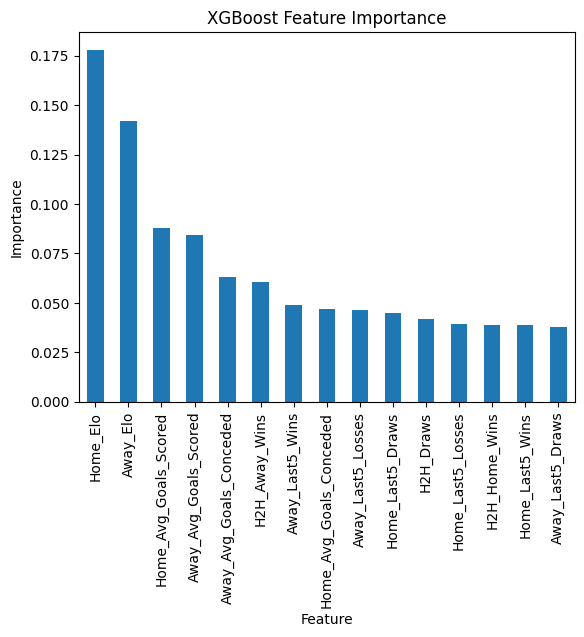

In [554]:
importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

importance.plot(kind="bar")
plt.title("XGBoost Feature Importance")
plt.ylabel("Importance")
plt.xlabel("Feature")
plt.show()